In [1]:
################################################################################
###                                                                          ###
### Created by Haotian XIAO, 2024-2027                                       ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
###                                                                          ###
### And Martin Genet, 2018-2025                                              ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
################################################################################

#################################################################### imports ###

import os
import math
import dolfin

import myPythonLibrary as mypy
import dolfin_mech as dmech


def run_gradp_linearity_test(
    r0_list=(0.2,),
    probe_list=("gx", "gy"),
    gradp_max=0.05,
    perform_tests=0,
):
    res_folder = "results_gradp_linearity"
    os.makedirs(res_folder, exist_ok=True)

    test = mypy.Test(
        res_folder=res_folder,
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    mat_params = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1,
        "eta": 1e-5,
    }

    dim = 2
    bcs = "pbc"

    print("res_folder =", res_folder)
    print("dim =", dim)
    print("bcs =", bcs)
    print("gradp_max =", gradp_max)

    def run_one_probe(r0, probe):
        pf = 0.0
        n_steps = 1

        if probe == "gx":
            gx_ini_lst = [0.0]
            gx_fin_lst = [gradp_max]
            gy_ini_lst = [0.0]
            gy_fin_lst = [0.01]

        elif probe == "gy":
            gx_ini_lst = [0.0]
            gx_fin_lst = [0.01]
            gy_ini_lst = [0.0]
            gy_fin_lst = [gradp_max]

        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = (
            f"gradp-linearity-r0={r0}-pf={pf}-{probe}"
        )

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][
                    "sigma_bar_" + str(i) + str(j)
                ] = 0.0

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0]
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0]

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst

        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0]
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0]

        load_params["liquid"]["Theta_out_ini_lst"] = [0.0]
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0]

        load_params["air"]["pf"] = pf

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3) / 2,
                "xmax": 1.0,
                "ymax": math.sqrt(3) / 2,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": (
                    res_folder
                    + f"/mesh-gradp-r0={r0}"
                ),
            },
            mat_params={
                "skel": {
                    "parameters": mat_params,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": mat_params,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": mat_params,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs=bcs,
            step_params={
                "n_steps": 1,
                "Deltat_lst": [1.0],
                "dt_ini_lst": [1e-3],
                "dt_min_lst": [1e-6],
                "dt_max_lst": [5e-3],
            },
            load_params=load_params,
            res_basename=res_folder + "/" + res_basename,
            verbose=0,
        )

        test.test(res_basename)

    for r0 in r0_list:
        for probe in probe_list:
            print(
                f"Running r0={r0}, "
                f"probe={probe}, "
                f"gradp_max={gradp_max}"
            )

            run_one_probe(
                r0=r0,
                probe=probe,
            )

    return res_folder

In [2]:
res_folder = run_gradp_linearity_test(
    r0_list=(0.315, 0.41),
    probe_list=("gx", "gy"),
    gradp_max=1.3,
    perform_tests=0,
)

res_folder = results_gradp_linearity
dim = 2
bcs = pbc
gradp_max = 1.3
Running r0=0.315, probe=gx, gradp_max=1.3
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Mes

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running r0=0.315, probe=gy, gradp_max=1.3
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy 

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src


2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-22 17:51:57.268 ( 916.193s) [          66524C]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x16329bba0): Unsupported cell type: 56 Sett

r0 = 0.315
phi = 0.2976749999999997
r0 = 0.41
phi = 0.5043000000000002


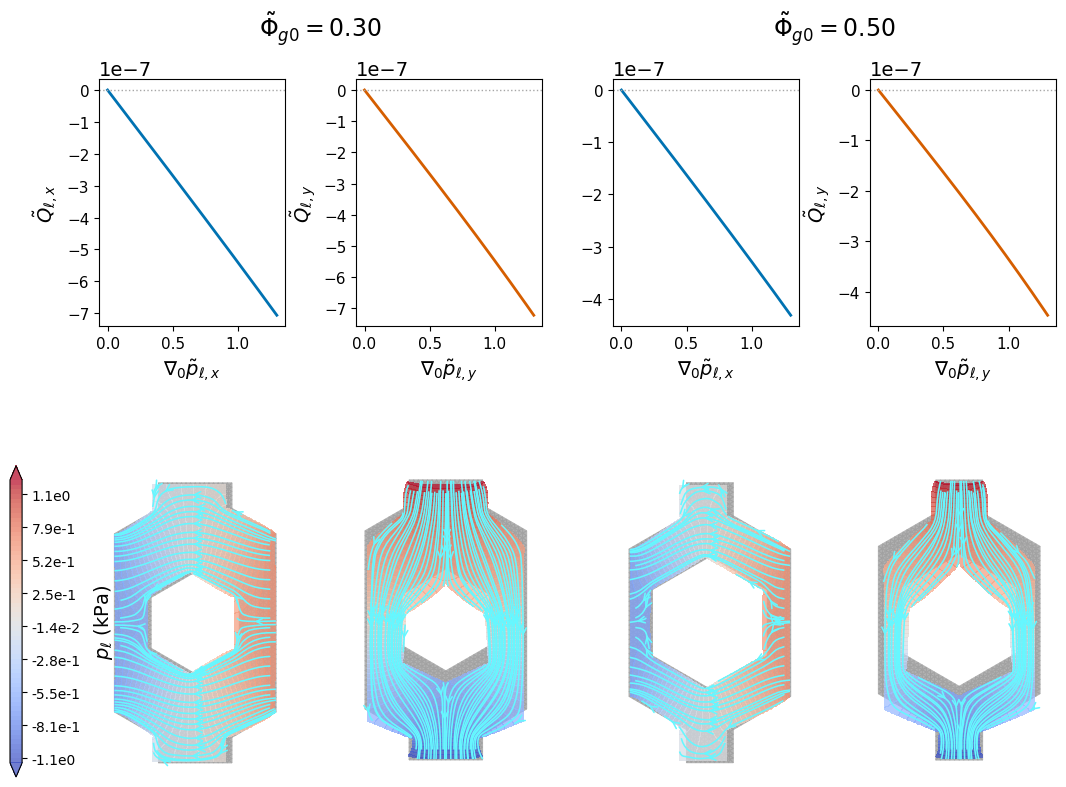

Saved: plots/q_vs_gradp_full.png


In [3]:
import importlib
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parents[0]
SRC_DIR = PROJECT_DIR / "src"

sys.path.insert(0, str(SRC_DIR))
print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)
from Plot_Microporoflow import plot_q_vs_gradp


results = plot_q_vs_gradp(
    res_folder="results_gradp_linearity",
    res_basename_prefix="gradp-linearity",
    r0_list=(0.315, 0.41),
    pf=0.0,
    slice_start=0,
    save_name="plots/q_vs_gradp_full.png",
    show_plot=True,
)